In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex

from IPython.display import display, Math, Latex
import ipywidgets as widgets
from matplotlib.widgets import Slider, Button

from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 
import matplotlib.ticker as ticker
import cmath

In [2]:
Delta = 0 #no detuning w0 - wp/2
w = 0 # ws-wp/2
kappa = 300e6*2*np.pi
drive = 0.2
theta = -np.pi/2
phi = 0
n_levels = 150
step = 30

In [3]:
lam_range = np.linspace(0,1.98,step)*kappa/4

In [4]:
a = qt.destroy(10)
qt.expect((a+a.dag())**4,qt.basis(10,0))

3.0000000000000004

In [4]:
def Gain_get_DPA(Delta, kappa, lam, drive, n_levels, theta, phi):
    
    a = qt.destroy(n_levels)
        
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a
    
    c_op_list = [np.sqrt(kappa) * a]
    epsilon = drive*kappa*np.exp(-1j*phi) #probe strength
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j * np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_DPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix

    g_DPA = Gain_DPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_DPA = 1/4 * np.abs(g_DPA[0,0] + g_DPA[1,1] + 1j*(g_DPA[1,0] - g_DPA[0,1]))**2
    
    ain_dag = ((-1j*Delta+kappa/2)*a.dag()-1j*np.conj(lam*np.exp(-1j*theta))*a)/np.sqrt(kappa) - 1j*np.conj(epsilon)/np.sqrt(kappa)
    
    vac = qt.basis(n_levels,0)
    exp_term_1 = 1/2 * qt.expect(ain_dag.dag()*ain_dag + ain_dag*ain_dag.dag(), vac)
    exp_term_2 = np.abs(qt.expect(ain_dag, vac))**2
    var_aindag = exp_term_1 - exp_term_2
    
    F = (Gain_DPA-1) * var_aindag / Gain_DPA
    wpump = 200e6*2*np.pi
    
    Coeff = kappa/4 + lam**2/kappa
    F_norm = F / Coeff
    
    eta = 1 / (1+2*F_norm)
    
    return g_DPA,Gain_DPA,F_norm,eta

In [5]:
# DPA
g_DPA11=[]
g_DPA12=[]
g_DPA21=[]
g_DPA22=[]
Gain_DPA=[]
noise_DPA=[]
eff_DPA=[]
analytic_DPA=[]



# Vary the pumping strength, n_levels and df
for lam in lam_range:
    
    a_Q,b_Q,c_Q,d_Q = Gain_get_DPA(Delta, kappa, lam, drive = drive, n_levels = n_levels, theta=theta, phi=0)
    g_DPA11.append(a_Q[0,0])
    g_DPA12.append(a_Q[0,1])
    g_DPA21.append(a_Q[1,0])
    g_DPA22.append(a_Q[1,1])
    Gain_DPA.append(b_Q)
    noise_DPA.append(c_Q)
    eff_DPA.append(d_Q)
    analytic_DPA.append(b_Q/(2*b_Q-1))

(0.0, 1.0)

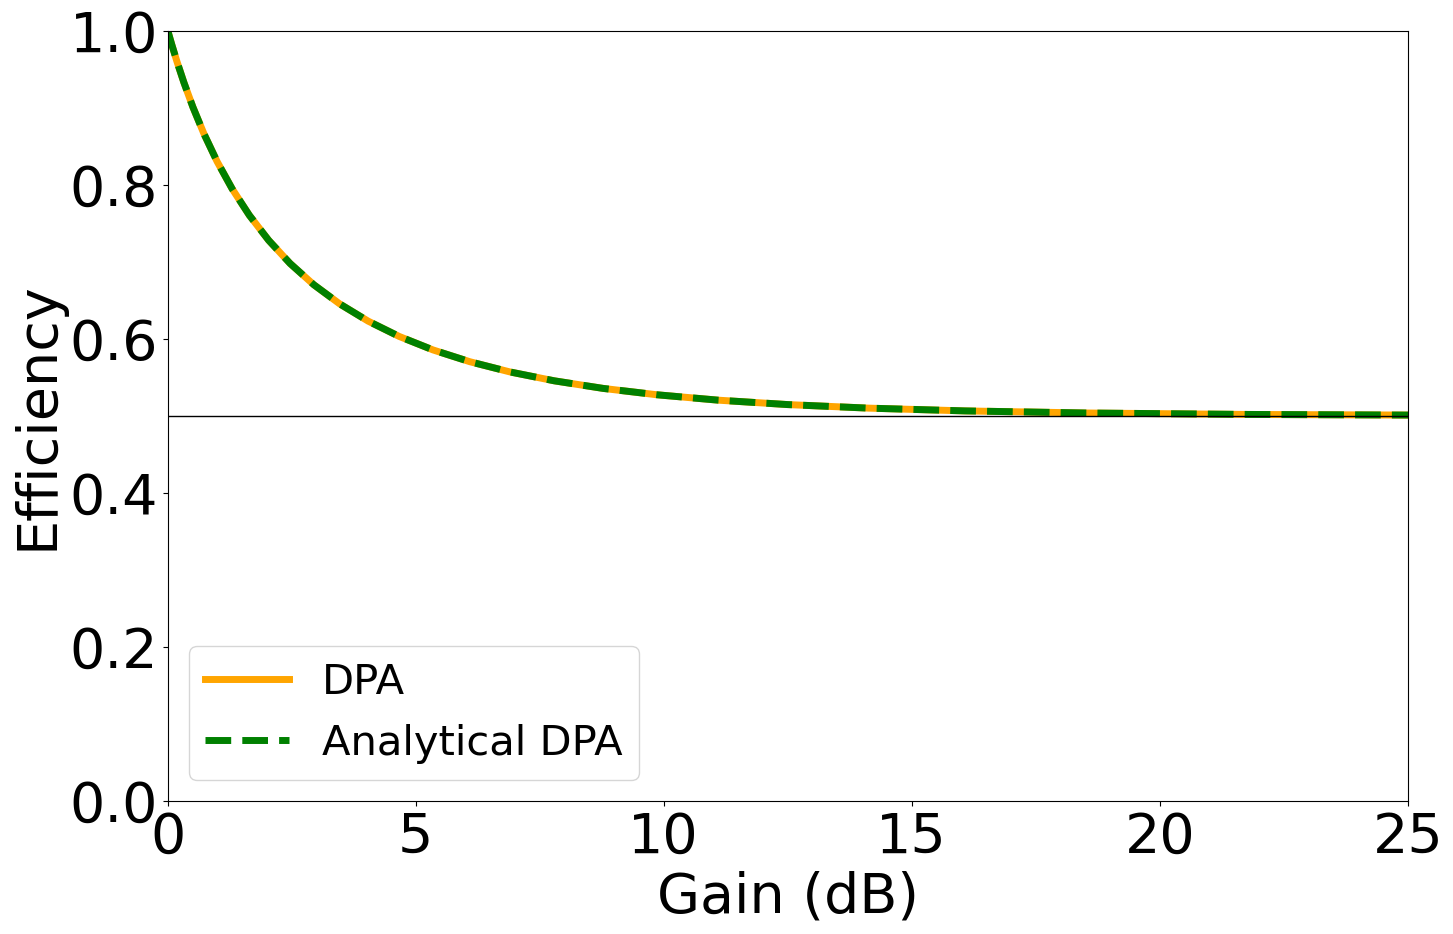

In [6]:
plt.figure(figsize=(16,10))
plt.plot(10*np.log10(Gain_DPA), eff_DPA,c='orange',linewidth=5, label = 'DPA')
plt.plot(10*np.log10(Gain_DPA), analytic_DPA, c='green', linestyle='--', linewidth=5, label = 'Analytical DPA')



list_x = np.linspace(0,30,10)
thresh = [0.5 for i in enumerate(list_x)]
plt.plot(list_x, thresh, c='black', linewidth=1)

plt.legend(loc='lower left', fontsize=30)
plt.xlabel('Gain (dB)',fontsize=40)
plt.ylabel('Efficiency',fontsize=40)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.xlim(0,25)
plt.ylim(0,1)
#plt.savefig("Efficiency plot.jpeg")

In [7]:
# JPA parameters
F_JPA = np.pi/4
EC_J = 85e5 * 2*np.pi #1e6 * 2*np.pi #85e4 * 2*np.pi
EJ = 1900e9 * 2*np.pi #2000e9 * 2*np.pi #2357e9 * 2*np.pi
phi_zpf_JPA = (2*EC_J/EJ)**0.25
JPA_ratio = phi_zpf_JPA**2/6 # |LAM/lam| ratio in abs value

Kerr = -EC_J * np.cos(F_JPA) / 2
print(Kerr/kappa)
print(JPA_ratio)

-0.010017346066809424
0.0004985358680134323


In [8]:
def Gain_get_JPA(Delta, kappa, lam, Kerr, drive, n, theta, phi, ratio):
    
    a = qt.destroy(n_levels)
    
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a

    LAM = - ratio * lam
    H_alpha = Kerr * a.dag() * a.dag() * a * a  + LAM *(a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a)
  
    c_op_list = [np.sqrt(kappa) * a]

    epsilon = drive*kappa*np.exp(-1j*phi)
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j*np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_JPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    g_JPA = Gain_JPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_JPA = 1/4 * np.abs(g_JPA[0,0] + g_JPA[1,1] + 1j*(g_JPA[1,0] - g_JPA[0,1]))**2
    gsw = cmath.sqrt(Gain_JPA)
    
    lam_DPA = 1j * kappa * cmath.sqrt(-1+gsw) / cmath.sqrt(-4-4*gsw)
    
    ain_dag = ((-1j*Delta+kappa/2)*a.dag()-1j*np.conj(lam*np.exp(-1j*theta))*a)/np.sqrt(kappa) - 1j*np.conj(epsilon)/np.sqrt(kappa) \
    - 1j*2*Kerr*a.dag()*a.dag()*a/np.sqrt(kappa) - 1j*LAM*(a.dag()*a.dag()*a.dag()+3*a.dag()*a*a) / np.sqrt(kappa)
    
    vac = qt.basis(n_levels,0)
    exp_term_1 = 1/2 * qt.expect(ain_dag.dag()*ain_dag + ain_dag*ain_dag.dag(), vac)
    exp_term_2 = np.abs(qt.expect(ain_dag, vac))**2
    var_aindag = exp_term_1 - exp_term_2
    
    F = (Gain_JPA-1) * var_aindag / Gain_JPA
    
    Coeff = kappa/4 + np.abs(lam_DPA)**2/kappa
    F_norm = F / Coeff
    
    eta = 1 / (1+2*F_norm)
    

    
    return g_JPA,Gain_JPA,F_norm,eta

In [9]:
# JPA with LAM=-1e-2*kappa
g_JPA11=[]
g_JPA12=[]
g_JPA21=[]
g_JPA22=[]
Gain_JPA=[]
noise_JPA=[]
eff_JPA=[]


for lam in -np.linspace(0.0,3.93,30)*kappa/4:
    aJ_Q,bJ_Q,cJ_Q,dJ_Q = Gain_get_JPA(Delta, kappa, lam, Kerr, drive, n_levels, theta, phi, JPA_ratio)
    g_JPA11.append(aJ_Q[0,0])
    g_JPA12.append(aJ_Q[0,1])
    g_JPA21.append(aJ_Q[1,0])
    g_JPA22.append(aJ_Q[1,1])
    Gain_JPA.append(bJ_Q)
    noise_JPA.append(cJ_Q)
    eff_JPA.append(dJ_Q)  

In [10]:
# KFJPA parameters

EC = 48e5 * 2*np.pi#85e4 * 2*np.pi #2e6 * 2*np.pi
EL = 1650e9 * 2*np.pi#140e9 * 2*np.pi #70e9 * 2*np.pi
phi_zps = (2*EC/EL)**0.25 
STS_ratio = phi_zps**2/6 # |LAM/lam| ratio in abs value
print(STS_ratio/JPA_ratio)
print(STS_ratio)

0.8063915796182054
0.0004020151261036849


In [11]:
def Gain_get_KFJPA(Delta, kappa, lam, drive, n_levels, theta, phi):
        
    a = qt.destroy(n_levels) 
    
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag()*a.dag() + lam*np.exp(1j*theta)/2 * a * a

    LAM = - STS_ratio * lam 
    H_alpha =  LAM * (a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a) 
   
    c_op_list = [np.sqrt(kappa) * a]

    epsilon = drive*kappa*np.exp(-1j*phi)
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j*np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    
    def Gain_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    g_KFJPA = Gain_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_KFJPA = 1/4 * np.abs(g_KFJPA[0,0] + g_KFJPA[1,1] + 1j*(g_KFJPA[1,0] - g_KFJPA[0,1]))**2
    gsw = cmath.sqrt(Gain_KFJPA)
    
    lam_DPA = 1j * kappa * cmath.sqrt(-1+gsw) / cmath.sqrt(-4-4*gsw)
    
    ain_dag = ((-1j*Delta+kappa/2)*a.dag()-1j*np.conj(lam*np.exp(-1j*theta))*a)/np.sqrt(kappa) - 1j*np.conj(epsilon)/np.sqrt(kappa)\
    + 1j*LAM*(a.dag()*a.dag()*a.dag()+3*a.dag()*a*a) / np.sqrt(kappa)
    
    vac = qt.basis(n_levels,0)
    exp_term_1 = 1/2 * qt.expect(ain_dag.dag()*ain_dag + ain_dag*ain_dag.dag(), vac)
    exp_term_2 = np.abs(qt.expect(ain_dag, vac))**2
    var_aindag = exp_term_1 - exp_term_2
    
    F = (Gain_KFJPA-1) * var_aindag / Gain_KFJPA
    
    Coeff = kappa/4 + np.abs(lam_DPA)**2/kappa
    F_norm = F / Coeff
    
    eta = 1 / (1+2*F_norm)

    return g_KFJPA,Gain_KFJPA,F_norm,eta

In [12]:
# KFJPA
g_KFJPA11=[]
g_KFJPA12=[]
g_KFJPA21=[]
g_KFJPA22=[]
Gain_KFJPA=[]
noise_KFJPA=[]
eff_KFJPA=[]


# Vary the pumping strength, n_levels and df
for lam in lam_range:
    
    af_Q,bf_Q,cf_Q,df_Q = Gain_get_KFJPA(Delta, kappa, lam, drive, n_levels, theta, phi)
    g_KFJPA11.append(af_Q[0,0])
    g_KFJPA12.append(af_Q[0,1])
    g_KFJPA21.append(af_Q[1,0])
    g_KFJPA22.append(af_Q[1,1])
    Gain_KFJPA.append(bf_Q)
    noise_KFJPA.append(cf_Q)
    eff_KFJPA.append(df_Q)

In [13]:
# JPA with LAM=-1e-2*kappa
gf_JPA11=[]
gf_JPA12=[]
gf_JPA21=[]
gf_JPA22=[]
Gainf_JPA=[]



for lam in lam_range:
    afJ_Q,bfJ_Q,cfJ_Q,dfJ_Q = Gain_get_JPA(Delta, kappa, lam, Kerr, drive, n_levels, theta, phi, JPA_ratio)
    gf_JPA11.append(afJ_Q[0,0])
    gf_JPA12.append(afJ_Q[0,1])
    gf_JPA21.append(afJ_Q[1,0])
    gf_JPA22.append(afJ_Q[1,1])
    Gainf_JPA.append(bfJ_Q)

In [14]:
# JPA parameters
F_JPA = np.pi/4
EC_J2 = 85e4 * 2*np.pi #1e6 * 2*np.pi #85e4 * 2*np.pi
EJ2 = 2000e9 * 2*np.pi #2000e9 * 2*np.pi #2357e9 * 2*np.pi
phi_zpf_JPA2 = (2*EC_J2/EJ2)**0.25
JPA_ratio2 = phi_zpf_JPA2**2/6 # |LAM/lam| ratio in abs value

Kerr2 = -EC_J2 * np.cos(F_JPA) / 2
print(Kerr2/kappa)
print(JPA_ratio2)

-0.0010017346066809425
0.00015365907428821477


In [15]:
# JPA with LAM=-1e-3*kappa
gf2_JPA11=[]
gf2_JPA12=[]
gf2_JPA21=[]
gf2_JPA22=[]
Gainf2_JPA=[]



for lam in lam_range:
    afJ2_Q,bfJ2_Q,cfJ2_Q,dfJ2_Q = Gain_get_JPA(Delta, kappa, lam, Kerr2, drive, n_levels, theta, phi, JPA_ratio2)
    gf2_JPA11.append(afJ2_Q[0,0])
    gf2_JPA12.append(afJ2_Q[0,1])
    gf2_JPA21.append(afJ2_Q[1,0])
    gf2_JPA22.append(afJ2_Q[1,1])
    Gainf2_JPA.append(bfJ2_Q)

In [16]:
# JPA parameters
F_JPA = np.pi/4
EC_J3 = 5*85e5 * 2*np.pi #1e6 * 2*np.pi #85e4 * 2*np.pi
EJ3 = 2000e9 * 2*np.pi #2000e9 * 2*np.pi #2357e9 * 2*np.pi
phi_zpf_JPA3 = (2*EC_J3/EJ3)**0.25
JPA_ratio3 = phi_zpf_JPA3**2/6 # |LAM/lam| ratio in abs value

Kerr3 = -EC_J3 * np.cos(F_JPA) / 2
print(Kerr3/kappa)
print(JPA_ratio3)

-0.05008673033404712
0.0010865337342004417


In [17]:
# JPA with LAM=-5e-2*kappa
gf3_JPA11=[]
gf3_JPA12=[]
gf3_JPA21=[]
gf3_JPA22=[]
Gainf3_JPA=[]



for lam in lam_range:
    afJ3_Q,bfJ3_Q,cfJ3_Q,dfJ3_Q = Gain_get_JPA(Delta, kappa, lam, Kerr3, drive, n_levels, theta, phi, JPA_ratio3)
    gf3_JPA11.append(afJ3_Q[0,0])
    gf3_JPA12.append(afJ3_Q[0,1])
    gf3_JPA21.append(afJ3_Q[1,0])
    gf3_JPA22.append(afJ3_Q[1,1])
    Gainf3_JPA.append(bfJ3_Q)

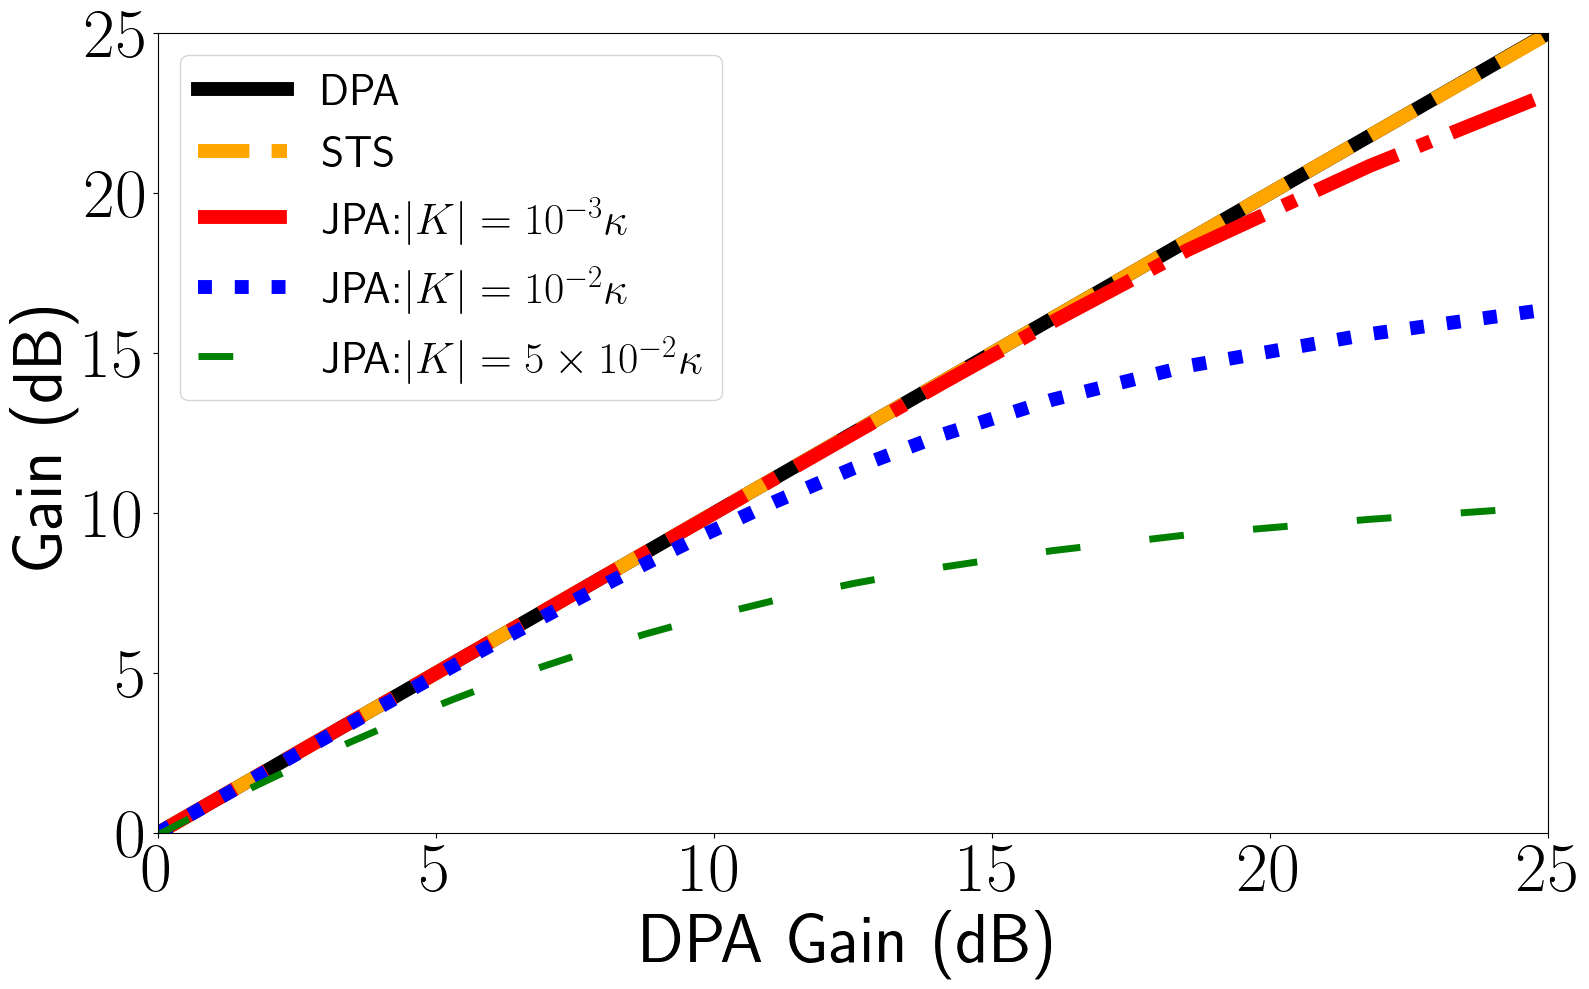

In [18]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
#plt.plot(10*np.log10(Gain_DPA), analytic_DPA, c='blue', linestyle=(0, (5, 10)), linewidth=10, label = 'Analytical DPA')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_DPA),c='black',linewidth=10, label = r'DPA')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_KFJPA),c='orange', linestyle='--',linewidth=10, label = r'STS')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf2_JPA),c='red',linestyle='-.', linewidth=10, label = r'JPA:$|K|=10^{-3}\kappa$')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf_JPA),c='blue',linestyle='dotted', linewidth=10, label = r'JPA:$|K|=10^{-2}\kappa$')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf3_JPA), c='green', linestyle=(0, (5, 10)), linewidth=5, label = r'JPA:$|K|=5\times 10^{-2}\kappa$')


plt.legend(loc='upper left', fontsize=32)
plt.xlabel(r'DPA Gain (dB)',fontsize=50)
plt.ylabel(r'Gain (dB)',fontsize=50)
plt.xticks(fontsize=50)
plt.yticks(fontsize=50)
plt.xlim(0,25)
plt.ylim(0,25)
plt.tight_layout()
plt.savefig("Gain plot paper.jpeg")

In [19]:
import pandas as pd

In [20]:
df = pd.read_csv('Gain_vs_BW.csv')

In [21]:
x_data = df['x_val']
y1_data = df['y_val_plot1']
y2_data = df['y_val_plot2']

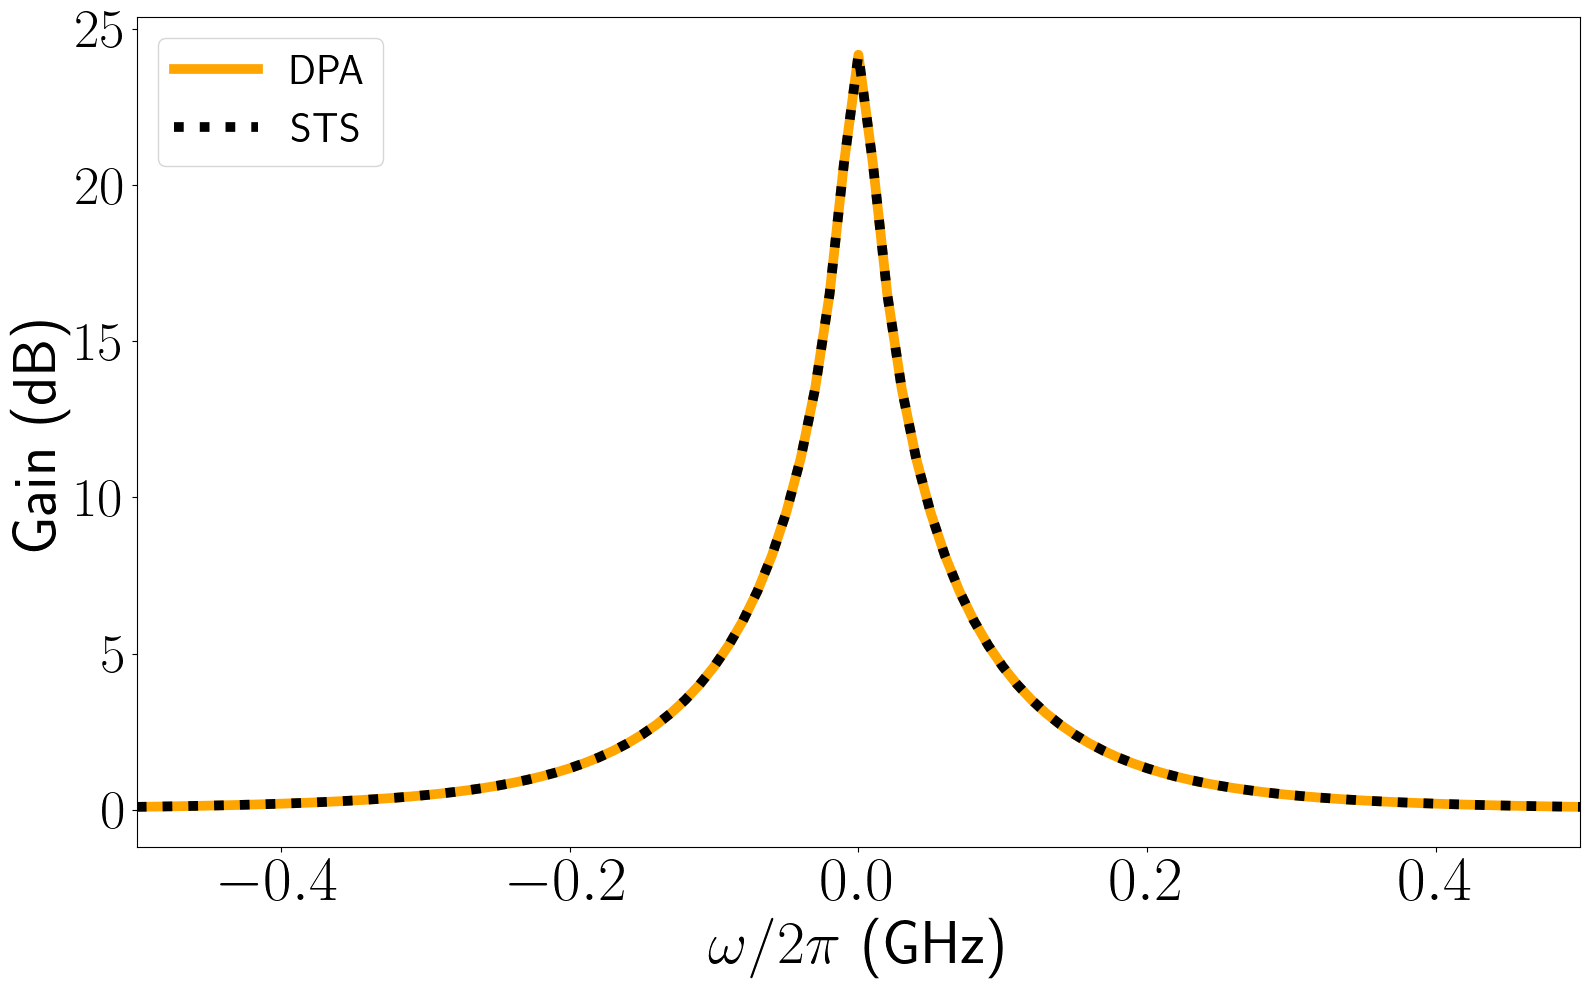

In [22]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
plt.plot(x_data, y1_data, c='orange', linewidth=7, label = 'DPA')
plt.plot(x_data, y2_data, c='black', linestyle='dotted', linewidth=7, label = 'STS')

plt.legend(loc='upper left', fontsize=30)
plt.ylabel('Gain (dB)', fontsize=44)
plt.xlabel(r'$\omega/2\pi$ (GHz)', fontsize=44)
plt.xlim(-0.5,0.5)
#plt.ylim(0,28)
#plt.title(r'$\Lambda=\lambda/235$', fontsize=40)
plt.xticks(fontsize=45)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.savefig("Gain plot analytical.jpeg")

C:\Users\kagan\AppData\Local\Temp\ipykernel_31228\3949185076.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


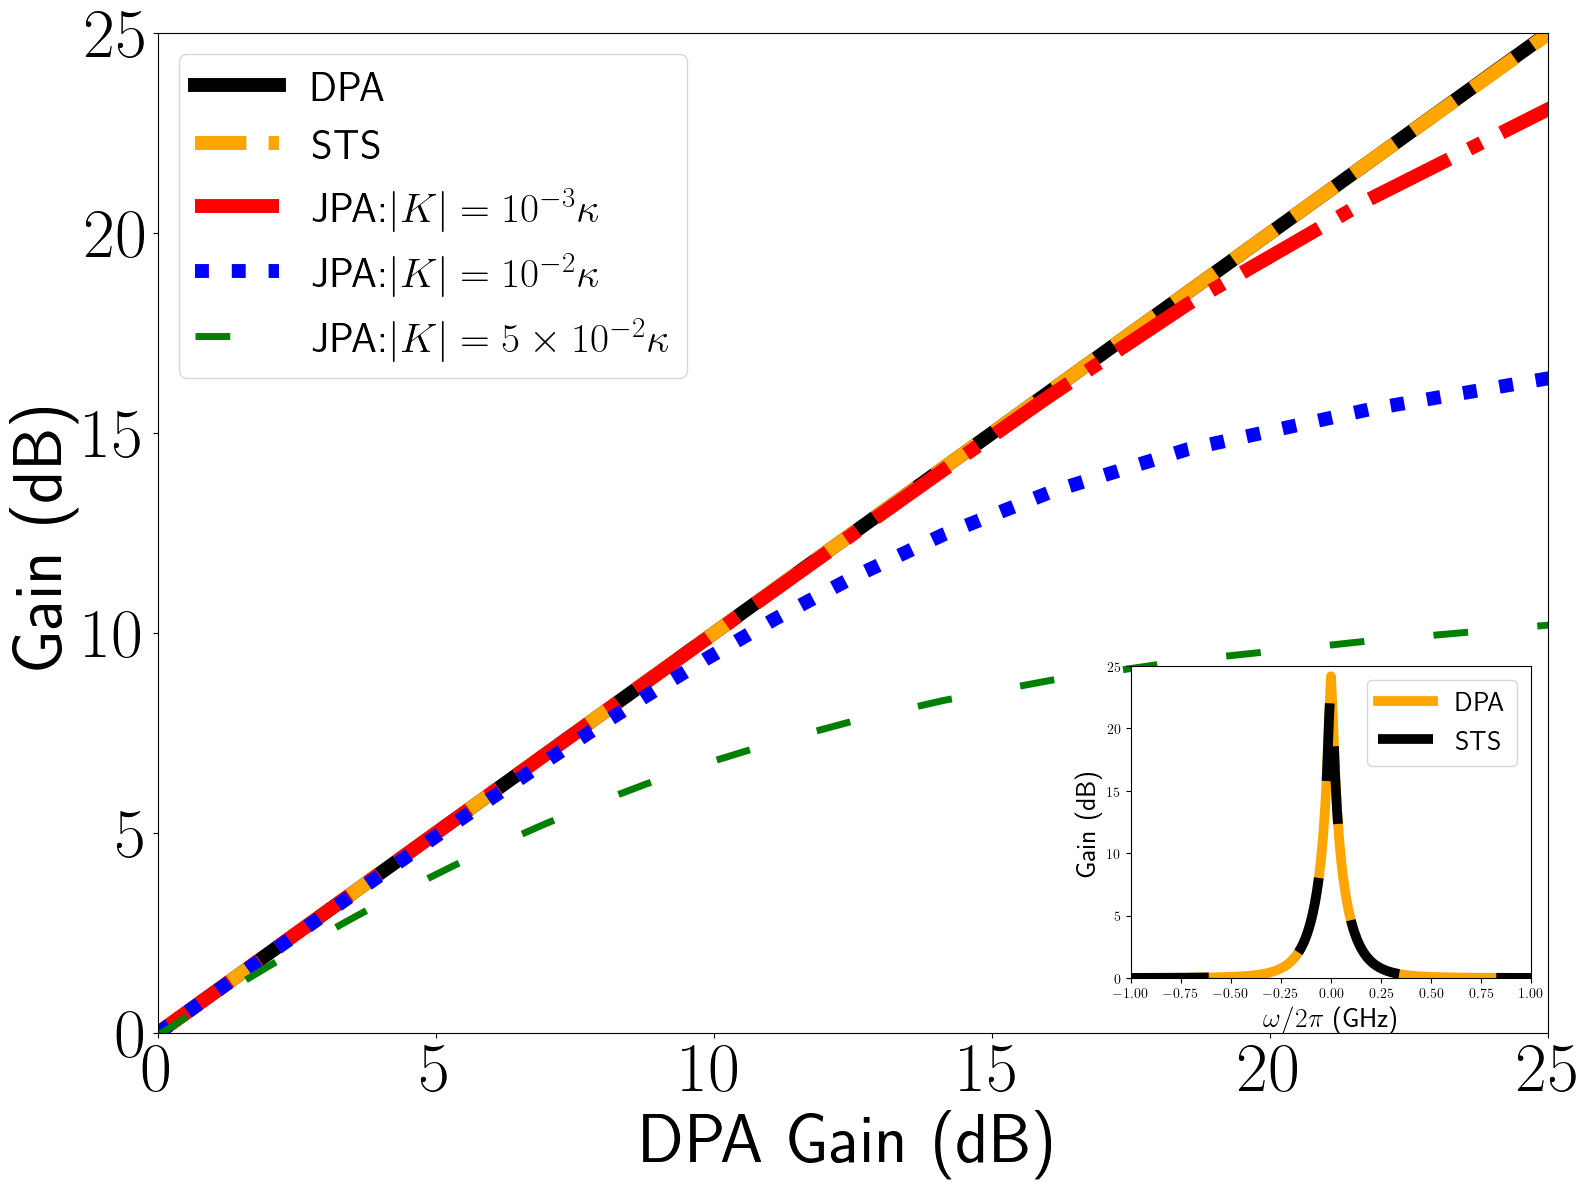

In [23]:
# These are in unitless percentages of the figure size. (0,0 is bottom left)
fig, ax1 = plt.subplots(figsize=(16, 12))
left, bottom, width, height = [0.71, 0.18, 0.25, 0.26]
ax2 = fig.add_axes([left, bottom, width, height])
plt.rcParams['text.usetex'] = True

ax1.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_DPA),c='black',linewidth=10, label = r'DPA')
ax1.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_KFJPA),c='orange', linestyle='--',linewidth=10, label = r'STS')
ax1.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf2_JPA),c='red',linestyle='-.', linewidth=10, label = r'JPA:$|K|=10^{-3}\kappa$')
ax1.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf_JPA),c='blue',linestyle='dotted', linewidth=10, label = r'JPA:$|K|=10^{-2}\kappa$')
ax1.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf3_JPA), c='green', linestyle=(0, (5, 10)), linewidth=5, label = r'JPA:$|K|=5\times 10^{-2}\kappa$')



ax1.set_ylabel(r'Gain (dB)',fontsize=50)
ax1.set_xlabel(r'DPA Gain (dB)',fontsize=50)
ax1.tick_params(axis='x', labelsize=50)
ax1.tick_params(axis='y', labelsize=50)
ax1.set_xlim(0,25)
ax1.set_ylim(0,25)

ax2.plot(x_data, y1_data, c='orange', linewidth=7, label = 'DPA')
ax2.plot(x_data, y2_data, c='black', linestyle=(0, (8, 10)), linewidth=7, label = 'STS')
ax2.set_ylim(0,25)
ax2.set_xlim(-1,1)
ax2.set_ylabel('Gain (dB)', fontsize=20)
ax2.set_xlabel(r'$\omega/2\pi$ (GHz)', fontsize=20)



ax1.legend(fontsize=30)
ax2.legend(fontsize=20)
#ax1.set_ylim(ymax = 0.07)
plt.tight_layout()
#plt.savefig("xxxxx.pdf")

In [24]:
print(Kerr/kappa, Kerr2/kappa, Kerr3/kappa)

-0.010017346066809424 -0.0010017346066809425 -0.05008673033404712


In [25]:
# JPA parameters
F_JPA = np.pi/4
EC_J4 = 1.5*85e5 * 2*np.pi #1e6 * 2*np.pi #85e4 * 2*np.pi
EJ4 = 2000e9 * 2*np.pi #2000e9 * 2*np.pi #2357e9 * 2*np.pi
phi_zpf_JPA4 = (2*EC_J4/EJ4)**0.25
JPA_ratio4 = phi_zpf_JPA4**2/6 # |LAM/lam| ratio in abs value

Kerr4 = -EC_J4 * np.cos(F_JPA) / 2
print(Kerr4/kappa)
print(JPA_ratio4)

-0.015026019100214137
0.0005951190357119042


In [26]:
# JPA with LAM=-2.5e-2*kappa
g4_JPA11=[]
g4_JPA12=[]
g4_JPA21=[]
g4_JPA22=[]
Gain4_JPA=[]
noise4_JPA=[]
eff4_JPA=[]


for lam in -np.linspace(0.0,8,30)*kappa/4:
    aJ4_Q,bJ4_Q,cJ4_Q,dJ4_Q = Gain_get_JPA(Delta, kappa, lam, Kerr3, drive, n_levels, theta, phi, JPA_ratio4)
    g4_JPA11.append(aJ4_Q[0,0])
    g4_JPA12.append(aJ4_Q[0,1])
    g4_JPA21.append(aJ4_Q[1,0])
    g4_JPA22.append(aJ4_Q[1,1])
    Gain4_JPA.append(bJ4_Q)
    noise4_JPA.append(cJ4_Q)
    eff4_JPA.append(dJ4_Q)  

In [27]:
# JPA parameters
F_JPA = np.pi/4
EC_J5 = 5*85e4 * 2*np.pi #1e6 * 2*np.pi #85e4 * 2*np.pi
EJ5 = 2000e9 * 2*np.pi #2000e9 * 2*np.pi #2357e9 * 2*np.pi
phi_zpf_JPA5 = (2*EC_J5/EJ5)**0.25
JPA_ratio5 = phi_zpf_JPA5**2/6 # |LAM/lam| ratio in abs value

Kerr5 = -EC_J5 * np.cos(F_JPA) / 2
print(Kerr5/kappa)
print(JPA_ratio5)

-0.005008673033404712
0.0003435921354681384


In [28]:
# JPA with LAM=-5e-3*kappa
g5_JPA11=[]
g5_JPA12=[]
g5_JPA21=[]
g5_JPA22=[]
Gain5_JPA=[]
noise5_JPA=[]
eff5_JPA=[]


for lam in -np.linspace(0.0,3.93,30)*kappa/4:
    aJ5_Q,bJ5_Q,cJ5_Q,dJ5_Q = Gain_get_JPA(Delta, kappa, lam, Kerr5, drive, n_levels, theta, phi, JPA_ratio5)
    g5_JPA11.append(aJ5_Q[0,0])
    g5_JPA12.append(aJ5_Q[0,1])
    g5_JPA21.append(aJ5_Q[1,0])
    g5_JPA22.append(aJ5_Q[1,1])
    Gain5_JPA.append(bJ5_Q)
    noise5_JPA.append(cJ5_Q)
    eff5_JPA.append(dJ5_Q)  

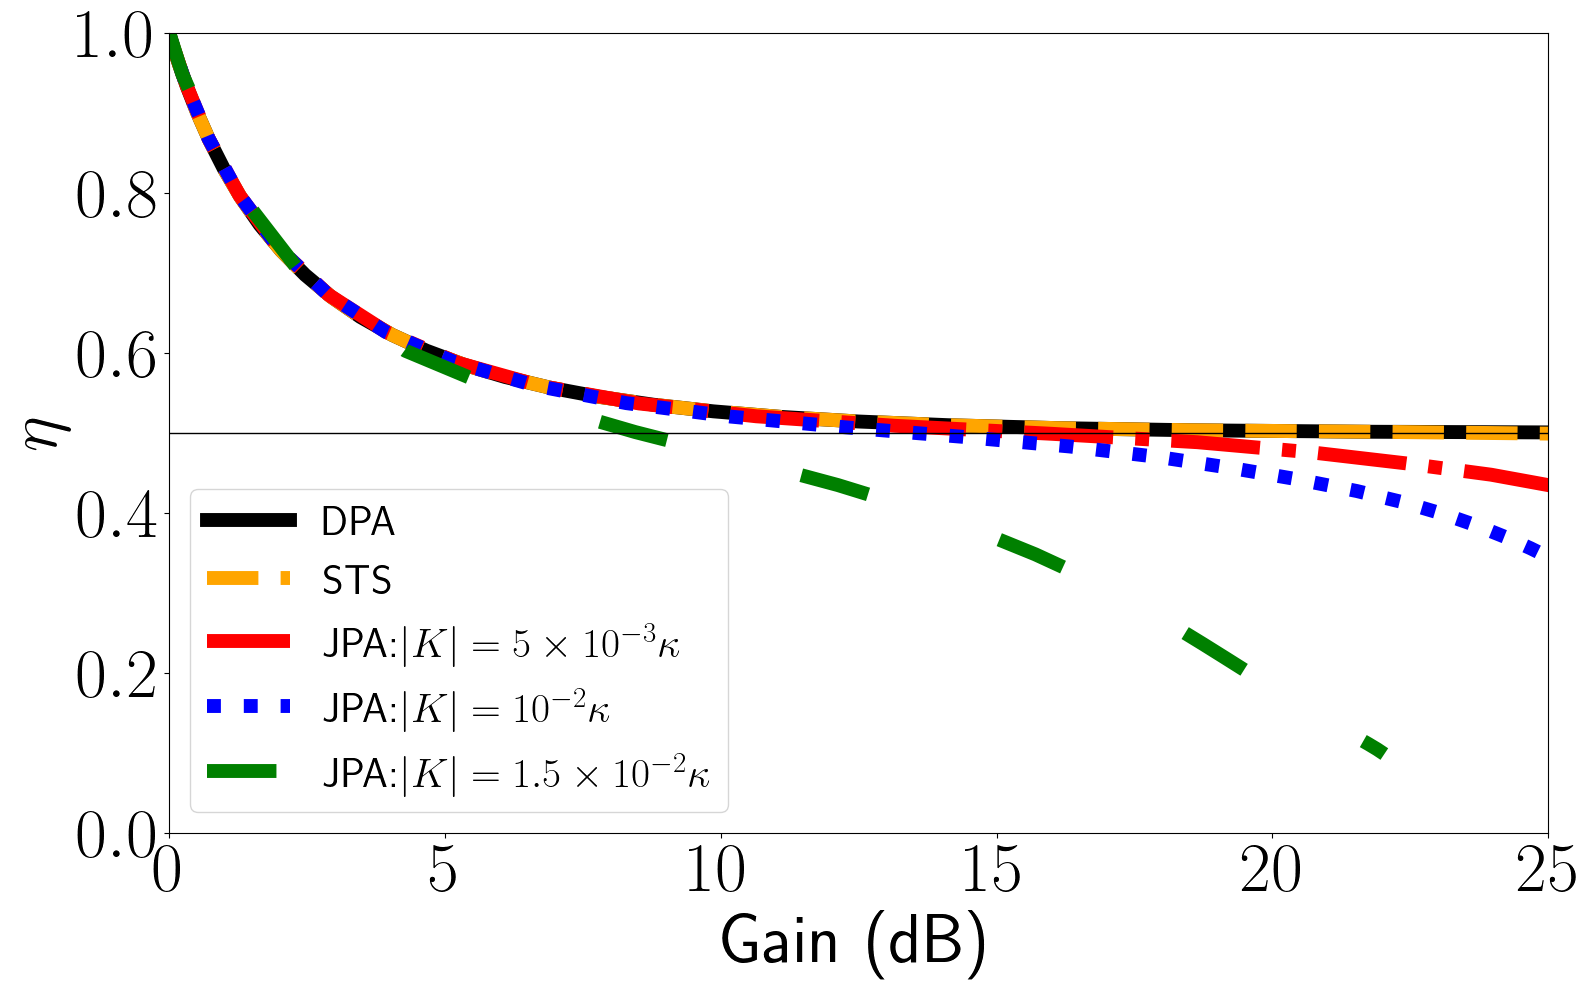

In [29]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
#plt.plot(10*np.log10(Gain_DPA), analytic_DPA, c='blue', linestyle=(0, (5, 10)), linewidth=10, label = r'Analytical DPA')
plt.plot(10*np.log10(Gain_DPA), eff_DPA,c='black',linewidth=10, label = r'DPA')
plt.plot(10*np.log10(Gain_KFJPA), eff_KFJPA,c='orange', linestyle='--',linewidth=10, label = r'STS')
plt.plot(10*np.log10(Gain5_JPA), eff5_JPA,c='red',linestyle='-.', linewidth=10, label = r'JPA:$|K|=5\times 10^{-3}\kappa$')
plt.plot(10*np.log10(Gain_JPA), eff_JPA,c='blue',linestyle='dotted', linewidth=10, label = r'JPA:$|K|=10^{-2}\kappa$')
plt.plot(10*np.log10(Gain4_JPA), eff4_JPA,c='green',linestyle=(0, (5, 10)), linewidth=10, label = r'JPA:$|K|=1.5\times 10^{-2}\kappa$')


list_x = np.linspace(0,30,10)
thresh = [0.5 for i in enumerate(list_x)]
plt.plot(list_x, thresh, c='black', linewidth=1)

plt.legend(loc='lower left', fontsize=30)
plt.xlabel(r'Gain (dB)',fontsize=50)
plt.ylabel(r'$\eta$',fontsize=50)
plt.xticks(fontsize=50)
plt.yticks(fontsize=50)
plt.xlim(0,25)
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("Efficiency plot paper.jpeg")

In [61]:
# Sample DataFrames for demonstration
gain1 = {'x_val': 10*np.log10(Gain_DPA), 'y_val_plot1': 10*np.log10(Gain_DPA)}
dfg1 = pd.DataFrame(gain1)

gain2 = {'x_val': 10*np.log10(Gain_DPA), 'y_val_plot2': 10*np.log10(Gain_KFJPA)}
dfg2 = pd.DataFrame(gain2)

gain3 = {'x_val': 10*np.log10(Gain_DPA), 'y_val_plot3': 10*np.log10(Gainf2_JPA)}
dfg3 = pd.DataFrame(gain3)

gain4 = {'x_val': 10*np.log10(Gain_DPA), 'y_val_plot4': 10*np.log10(Gainf_JPA)}
dfg4 = pd.DataFrame(gain4)

gain5 = {'x_val': 10*np.log10(Gain_DPA), 'y_val_plot5': 10*np.log10(Gainf3_JPA)}
dfg5 = pd.DataFrame(gain5)



# Option 1: Concatenate if columns are different or you want to keep them separate
combined_dfg_option1 = pd.concat([dfg1, dfg2, dfg3, dfg4, dfg5], axis=1)

In [62]:
# Exporting the first option (side-by-side columns)
combined_dfg_option1.to_csv('PP Gain.csv', index=False)


In [64]:
eff1 = {'x_val': 10*np.log10(Gain_DPA), 'y_val_plot1': eff_DPA}
dfe1 = pd.DataFrame(eff1)

eff2 = {'x_val': 10*np.log10(Gain_KFJPA), 'y_val_plot2': eff_KFJPA}
dfe2 = pd.DataFrame(eff2)

eff3 = {'x_val': 10*np.log10(Gain5_JPA), 'y_val_plot3': eff5_JPA}
dfe3 = pd.DataFrame(eff3)

eff4 = {'x_val': 10*np.log10(Gain_JPA), 'y_val_plot4': eff_JPA}
dfe4 = pd.DataFrame(eff4)

eff5 = {'x_val': 10*np.log10(Gain4_JPA), 'y_val_plot5': eff4_JPA}
dfe5 = pd.DataFrame(eff5)

# Option 1: Concatenate if columns are different or you want to keep them separate
combined_dfe_option1 = pd.concat([dfe1, dfe2, dfe3, dfe4, dfe5], axis=1)

In [65]:
# Exporting the first option (side-by-side columns)
combined_dfe_option1.to_csv('PP Efficiency.csv', index=False)


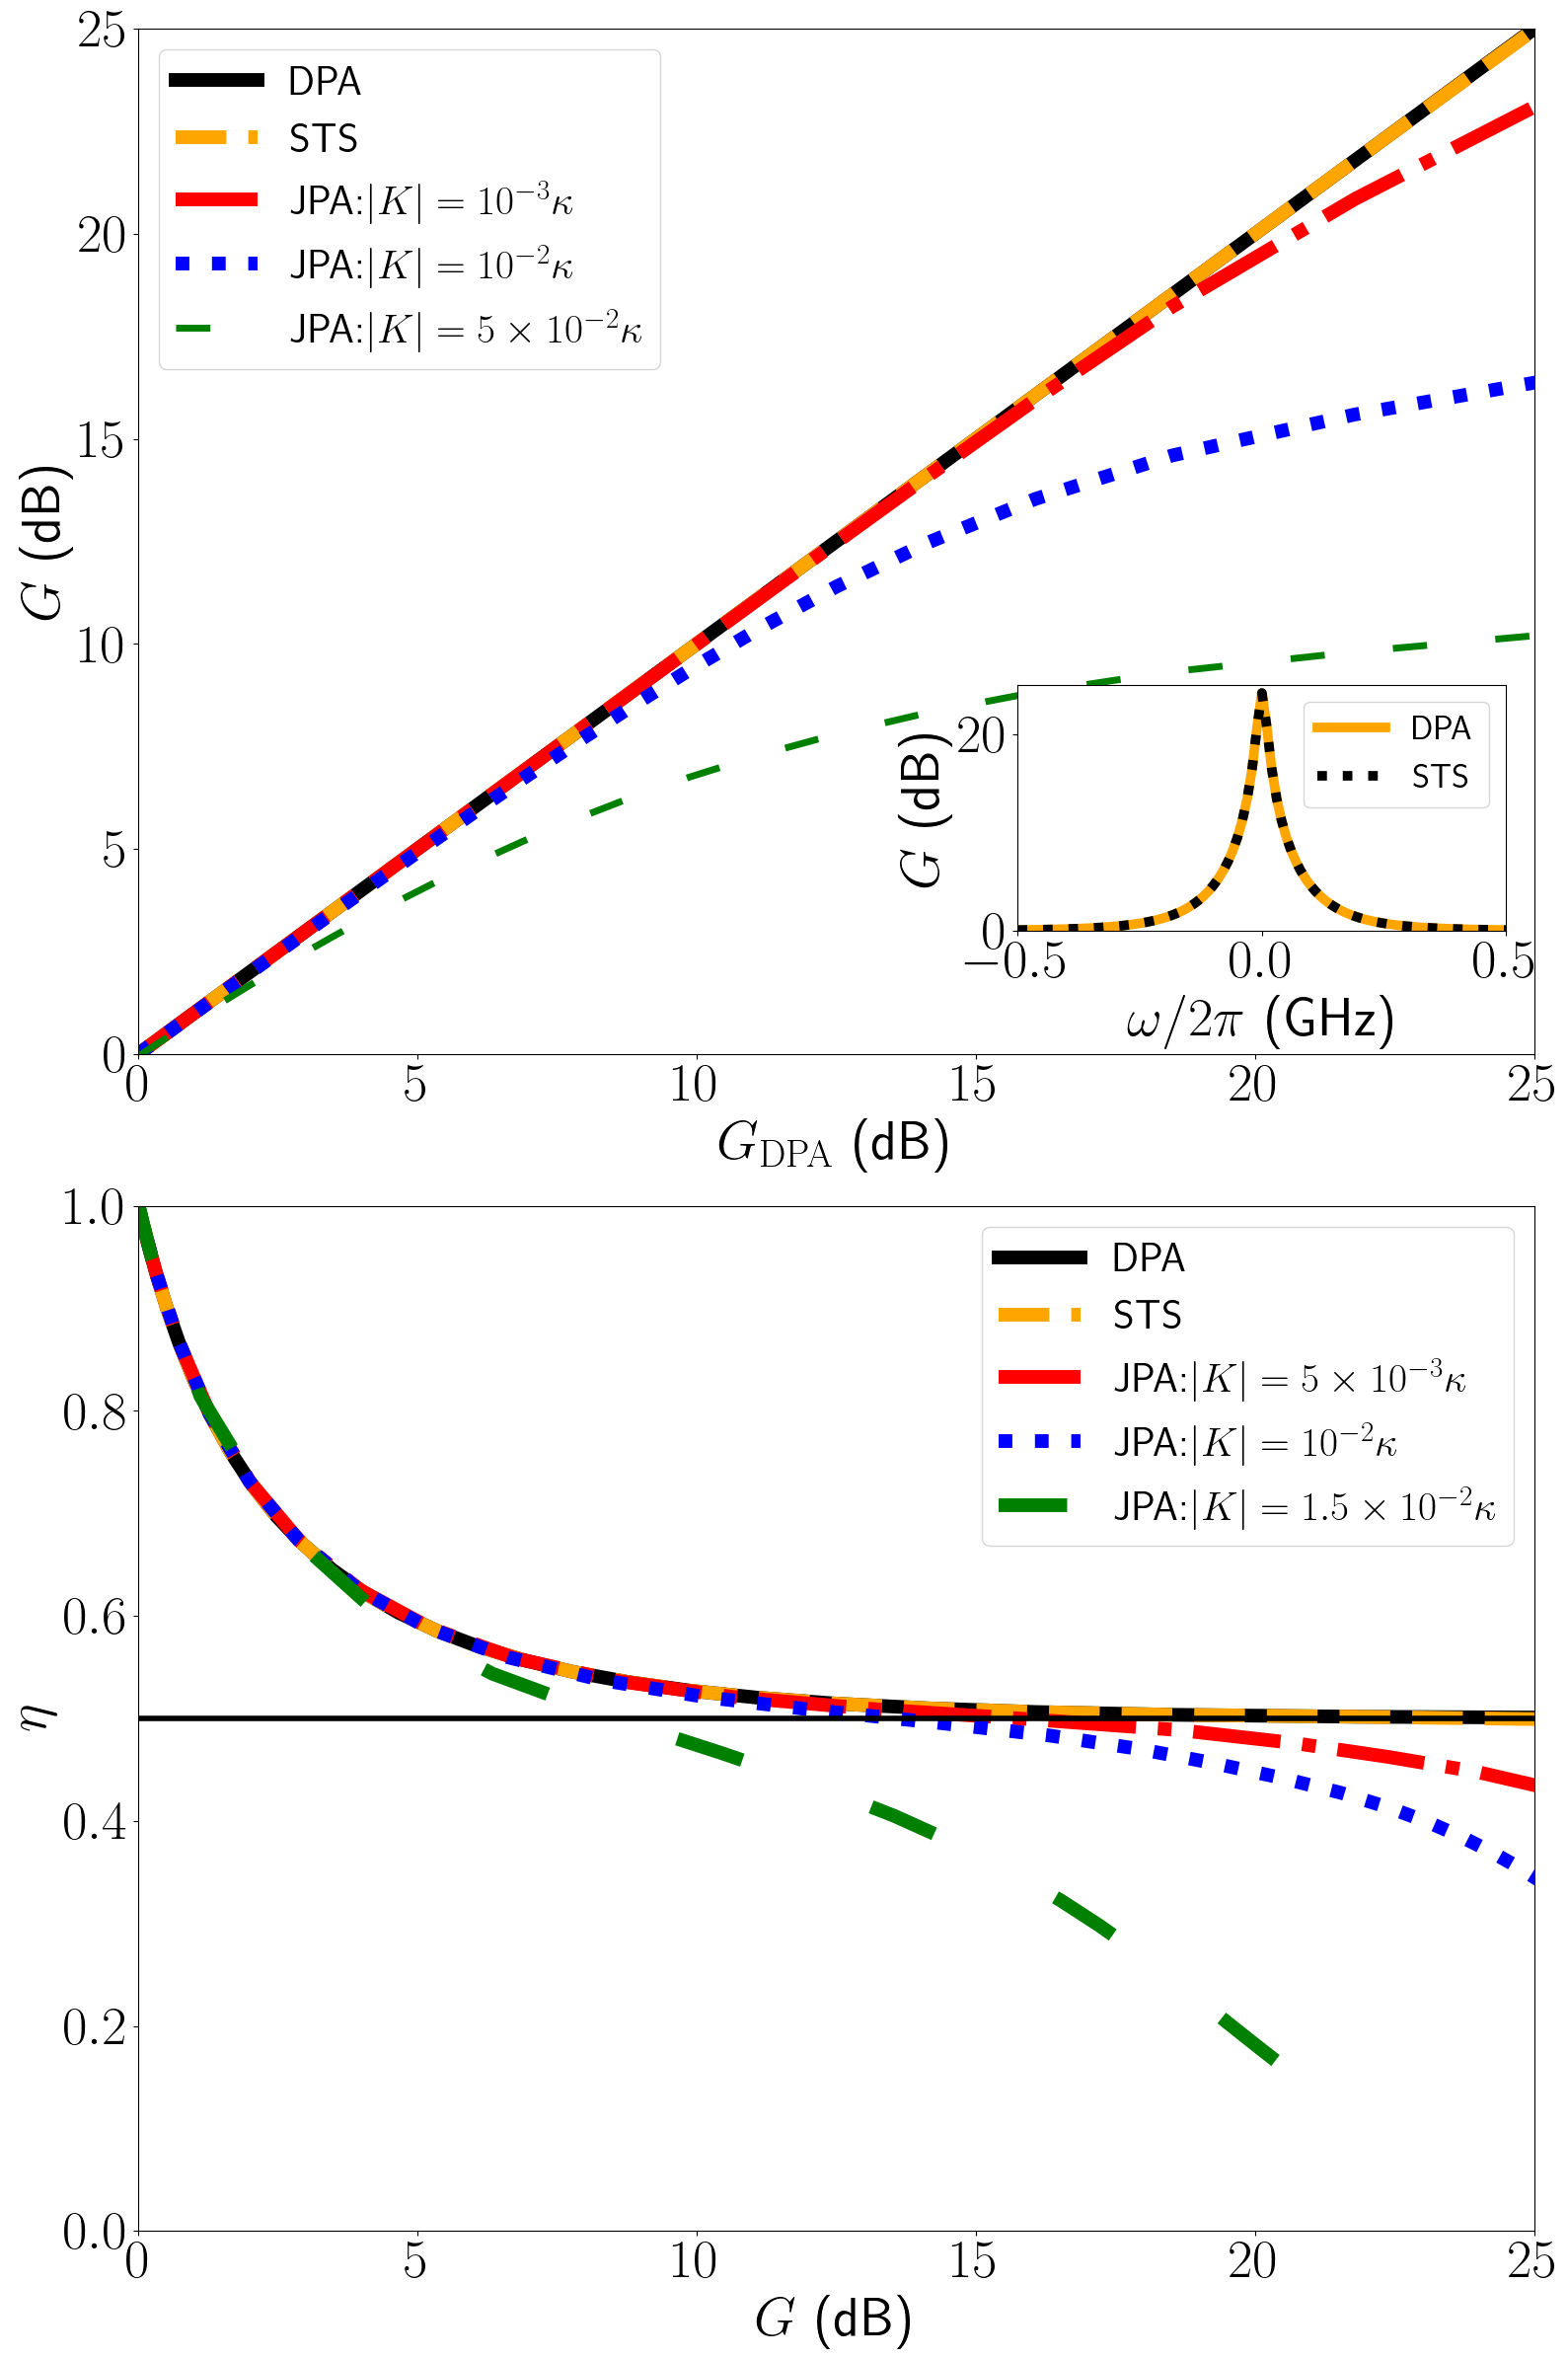

In [57]:
# Create figure and two subplots arranged top to bottom
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(16, 24))

# Plot on the top subplot
plt.rcParams['text.usetex'] = True

ax_top.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_DPA),c='black',linewidth=10, label = r'DPA')
ax_top.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_KFJPA),c='orange', linestyle='--',linewidth=10, label = r'STS')
ax_top.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf2_JPA),c='red',linestyle='-.', linewidth=10, label = r'JPA:$|K|=10^{-3}\kappa$')
ax_top.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf_JPA),c='blue',linestyle='dotted', linewidth=10, label = r'JPA:$|K|=10^{-2}\kappa$')
ax_top.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainf3_JPA), c='green', linestyle=(0, (5, 10)), linewidth=5, label = r'JPA:$|K|=5\times 10^{-2}\kappa$')



ax_top.set_ylabel(r'$G$ (dB)',fontsize=40)
ax_top.set_xlabel(r'$G_\mathrm{DPA}$ (dB)',fontsize=40)
ax_top.tick_params(axis='x', labelsize=40)
ax_top.tick_params(axis='y', labelsize=40)
ax_top.set_xlim(0,25)
ax_top.set_ylim(0,25)
ax_top.legend(fontsize=30)

# Plot on the bottom subplot
ax_bottom.plot(10*np.log10(Gain_DPA), eff_DPA,c='black',linewidth=10, label = r'DPA')
ax_bottom.plot(10*np.log10(Gain_KFJPA), eff_KFJPA,c='orange', linestyle='--',linewidth=10, label = r'STS')
ax_bottom.plot(10*np.log10(Gain5_JPA), eff5_JPA,c='red',linestyle='-.', linewidth=10, label = r'JPA:$|K|=5\times 10^{-3}\kappa$')
ax_bottom.plot(10*np.log10(Gain_JPA), eff_JPA,c='blue',linestyle='dotted', linewidth=10, label = r'JPA:$|K|=10^{-2}\kappa$')
ax_bottom.plot(10*np.log10(Gain4_JPA), eff4_JPA,c='green',linestyle=(0, (5, 10)), linewidth=10, label = r'JPA:$|K|=1.5\times 10^{-2}\kappa$')

list_x = np.linspace(0,30,10)
thresh = [0.5 for i in enumerate(list_x)]
ax_bottom.plot(list_x, thresh, c='black', linewidth=4)

ax_bottom.set_ylabel(r'$\eta$',fontsize=40)
ax_bottom.set_xlabel(r'$G$ (dB)',fontsize=40)
ax_bottom.tick_params(axis='x', labelsize=40)
ax_bottom.tick_params(axis='y', labelsize=40)
ax_bottom.set_xlim(0,25)
ax_bottom.set_ylim(0,1)
ax_bottom.legend(fontsize=30)

# Create an inset axes within the top subplot
# [x, y, width, height] relative to ax_top
ax_inset = ax_top.inset_axes([0.63, 0.12, 0.35, 0.24])

# Plot data on the inset axes
ax_inset.plot(x_data, y1_data, c='orange', linewidth=7, label = 'DPA')
ax_inset.plot(x_data, y2_data, c='black', linestyle='dotted', linewidth=7, label = 'STS')
ax_inset.set_ylim(0,25)
ax_inset.set_xlim(-0.5,0.5)
ax_inset.set_ylabel(r'$G$ (dB)', fontsize=40)
ax_inset.set_xlabel(r'$\omega/2\pi$ (GHz)', fontsize=40)
ax_inset.tick_params(axis='x', labelsize=40)
#ax_inset.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.2f}"))
ax_inset.set_xticks([-0.5,0,0.5])
ax_inset.tick_params(axis='y', labelsize=40)
ax_inset.legend(fontsize=25)
#ax_inset.tick_params(labelleft=False, labelbottom=False) # Hide inset ticks for cleaner look


plt.tight_layout()
plt.savefig("Gain and Efficiency plots.jpeg")
plt.show()
